## **AI and Machine Learning Part B (Regression)**

<b>Name:</b> Khambhati Moiz Huzefa

<b>Class:</b> DAAA/FT/1B/01

<b>Admin No:</b> P2508625

<br>

### **Background Information**

This assignment uses the **`housing_price_data.csv`** dataset, which was collected from various housing markets across the United States. The dataset includes multiple property-related attributes such as **region**, **city**, **house area**, **number of bedrooms and toilets**, **stories**, and **renovation status**.

From a **real estate analysis** perspective, the objective is to build a **machine learning model** that can predict the **sale price of a house** based on these attributes. This regression task supports **property valuation and investment decisions**, helping stakeholders estimate market prices accurately and identify key factors that influence housing costs.

---


<br>

### **Objectives for This Assignment**

The primary objective of this assignment is to apply the full **machine learning workflow** to a real-world **regression task** that predicts the sale price of houses based on their features.
This project demonstrates the ability to preprocess data, engineer meaningful features, train and evaluate regression models, and fine-tune their performance for accurate price prediction.

#### **Specific Objectives**

* Use **pandas** and **NumPy** for efficient data loading, cleaning, and transformation.
* Conduct **Exploratory Data Analysis (EDA)** to identify patterns, outliers, and relationships between features such as house size, number of rooms, and renovation status.
* Perform **data preprocessing** and **feature engineering**, including encoding categorical variables and creating derived ratios or interactions that better represent property characteristics.
* Develop and compare multiple **regression algorithms**, such as **Linear Regression**, **Gradient Boosting Regressor**, and **Random Forest Regressor**.
* Apply **hyperparameter tuning** using **GridSearchCV** to optimize model parameters for better predictive accuracy.
* Evaluate model performance using regression metrics including **Mean Absolute Error (MAE)** and **R² score**, ensuring models are both accurate and generalizable.
* Visualize model performance and feature importance using **Seaborn** and **Matplotlib** to support interpretability and insights.
* Reflect on how **data preprocessing**, **feature engineering**, and **hyperparameter tuning** influence model accuracy and robustness.

Ultimately, the goal is to build a **high-performing regression model** capable of accurately estimating housing prices, demonstrating a strong understanding of the complete **machine learning pipeline** from raw data to refined prediction.

---


<br>

### **Importing the libraries required**

In [101]:
# === Data Processing ===
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# === Models ===
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.dummy import DummyRegressor

# === Evaluation ===
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

# === Data Visualization ===
import seaborn as sns
import matplotlib.pyplot as plt


<br>

### **Data Understanding**

The dataset used in this study, *housing_price_data.csv*, contains information on residential properties across various U.S. cities. Each record represents a single house and provides details about its **physical attributes**, **location**, and **renovation status**, along with its corresponding **sale price**. The dataset consists of **545 observations** and **8 features**, including both numerical and categorical variables such as *House Area (sqm)*, *No. of Bedrooms*, *Stories*, and *City*.

The main objective of this analysis is to build a **predictive model** that can estimate the **sale price of a house** based on its features. This defines a **regression problem**, where the goal is to predict a **continuous numerical value** — the price of the property. The input features, including *House Area*, *No. of Bedrooms*, *No. of Toilets*, *Stories*, *City*, and *Renovation Status*, collectively influence the model’s price estimation.

The **output variable**, *Price ($)*, represents the **predicted sale price** of the house and serves as the **target variable** for the regression model. A higher predicted price generally reflects properties with larger areas, better renovation status, or more desirable city locations.

Understanding how these features interact allows for identifying which factors most strongly affect housing prices, enabling data-driven insights for **real estate valuation**, **market analysis**, and **investment decision-making**.

---


<br>

### **Data Overview**

The dataset, **housing_price_data**, contains information about residential properties from various cities across the United States. It includes **545 records and 8 attributes**, each describing a specific characteristic of a house or its sale price. The variables are summarized below:

| **Feature Name**      | **Description**                                                                             |
| --------------------- | ------------------------------------------------------------------------------------------- |
| **House ID**          | A unique identifier assigned to each property.                                              |
| **City**              | The city where the property is located (e.g., Chicago, Denver, Seattle, New York).          |
| **House Area (sqm)**  | The total built-up area of the house measured in **square meters (sqm)**.                   |
| **No. of Bedrooms**   | The total number of bedrooms available in the property.                                     |
| **No. of Toilets**    | The total number of toilets available in the property.                                      |
| **Stories**           | The number of floors or levels in the house.                                                |
| **Renovation Status** | Indicates the furnishing condition — **furnished**, **semi-furnished**, or **unfurnished**. |
| **Price ($)**         | The target variable representing the **sale price** of the property in U.S. dollars.        |

The dataset contains a mix of **categorical** variables (*City*, *Renovation Status*) and **numerical** variables (*House Area*, *No. of Bedrooms*, *Stories*, etc.), offering a well-rounded view of the factors that influence property valuation.

This combination of structural and locational features makes the dataset ideal for constructing a **machine learning regression model** that predicts house prices based on physical characteristics, furnishing condition, and location.

---


<br>

### **Explanatory Data Analysis of factory_data.csv Dataset**

In [102]:

# Importing the dataset housing_price_data.csv as df
df = pd.read_csv("datasets/housing_price_data.csv")

print("Shape:",df.shape)
print("\nIndex:",df.index)
print("\nColumns:",df.columns)
print("\nCount of non-missing values:\n",df.count())
print("\nDataFrame Info:\n")
df.info()
print("\nDescriptive Statistics:\n", df.describe())
print("\nData Types: \n", df.dtypes)
print("\nFirst 5 records in DataFrame")
df.head()


Shape: (545, 8)

Index: RangeIndex(start=0, stop=545, step=1)

Columns: Index(['House ID', 'City', 'House Area (sqm)', 'No. of Bedrooms',
       'No. of Toilets', 'Stories', 'Renovation Status', 'Price ($)'],
      dtype='object')

Count of non-missing values:
 House ID             545
City                 545
House Area (sqm)     545
No. of Bedrooms      545
No. of Toilets       545
Stories              545
Renovation Status    545
Price ($)            545
dtype: int64

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   House ID           545 non-null    int64  
 1   City               545 non-null    object 
 2   House Area (sqm)   545 non-null    float64
 3   No. of Bedrooms    545 non-null    int64  
 4   No. of Toilets     545 non-null    int64  
 5   Stories            545 non-null    int64  
 6   Renovation Sta

,House ID,City,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($)
0,0,Chicago,742.0,4,2,3,furnished,1330000
1,1,Denver,896.0,4,4,4,furnished,1225000
2,2,Chicago,996.0,3,2,2,semi-furnished,1225000
3,3,Seattle,750.0,4,2,2,furnished,1221500
4,4,New York,742.0,4,1,2,furnished,1141000


<br>

### **Initial Data Inspection**

The dataset, `housing_price_data.csv`, contains **545 records and 8 columns**, representing property listings with details on location, physical structure, renovation status, and sale price. The index ranges from 0 to 544, with each entry corresponding to an individual house.

#### **Dataset Structure**

The dataset includes both categorical and numerical features:

* **Categorical Columns:** `City`, `Renovation Status`
* **Numerical Columns:** `House ID`, `House Area (sqm)`, `No. of Bedrooms`, `No. of Toilets`, `Stories`, `Price ($)`

From the data types summary, five columns are stored as `int64`, one as `float64`, and two as `object` types. This balanced mix of data types provides opportunities for both **encoding categorical variables** and **scaling numerical ones** during preprocessing.

#### **Missing Values**

All columns are **complete**, with **no missing values** detected. Each of the 545 observations contains full information for every feature, making the dataset clean and ready for exploratory data analysis without requiring imputation.

#### **Descriptive Statistics**

The numerical features exhibit clear and interpretable ranges:

* **House Area (sqm):** Ranges from **165** to **1,620 sqm**, with an average area of approximately **515 sqm**.
* **No. of Bedrooms:** Varies between **1 and 6**, with an average of **3 bedrooms per house**.
* **No. of Toilets:** Typically **1–4**, averaging around **1.3 toilets per house**.
* **Stories:** Houses have between **1 and 4 stories**, with most properties being **1–2 storeys tall**.
* **Price ($):** Sale prices range from **$175,000** to **$1,330,000**, with a mean of around **$476,000**, suggesting a moderate spread in property values across cities.

#### **Initial Observations**

The dataset is **complete, consistent, and well-structured**, containing a balanced variety of features suitable for regression modeling. The spread in *house area* and *price* indicates a healthy range for learning relationships between property characteristics and sale value.

Further analyses — including **distribution visualizations** and a **correlation matrix** — will help identify potential relationships, detect outliers, and highlight which factors most strongly influence housing prices.


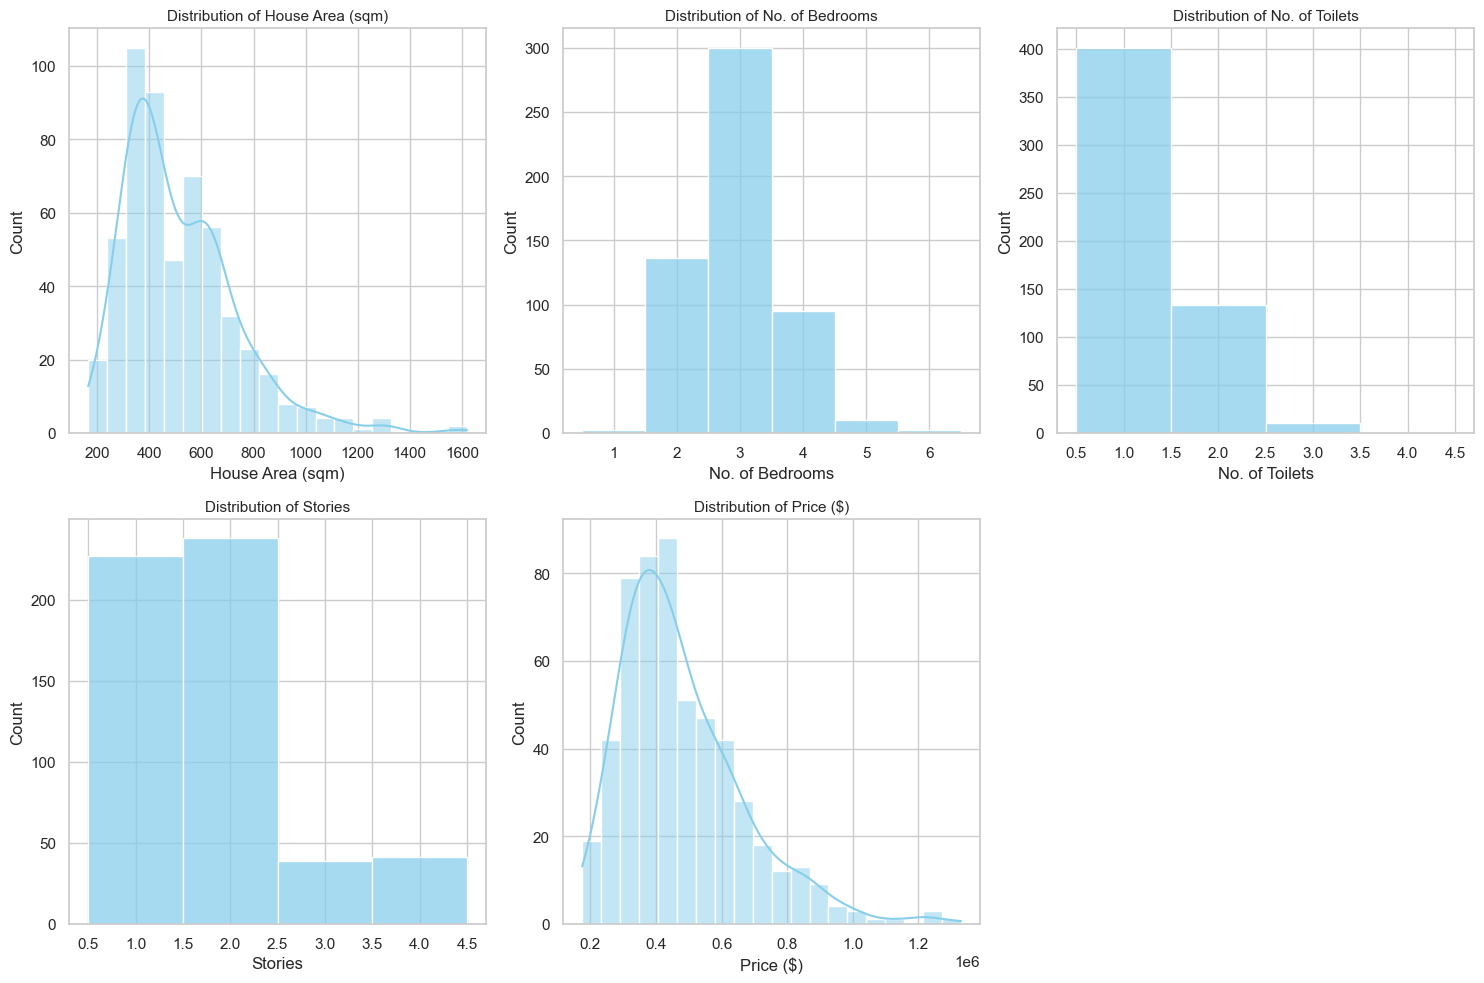

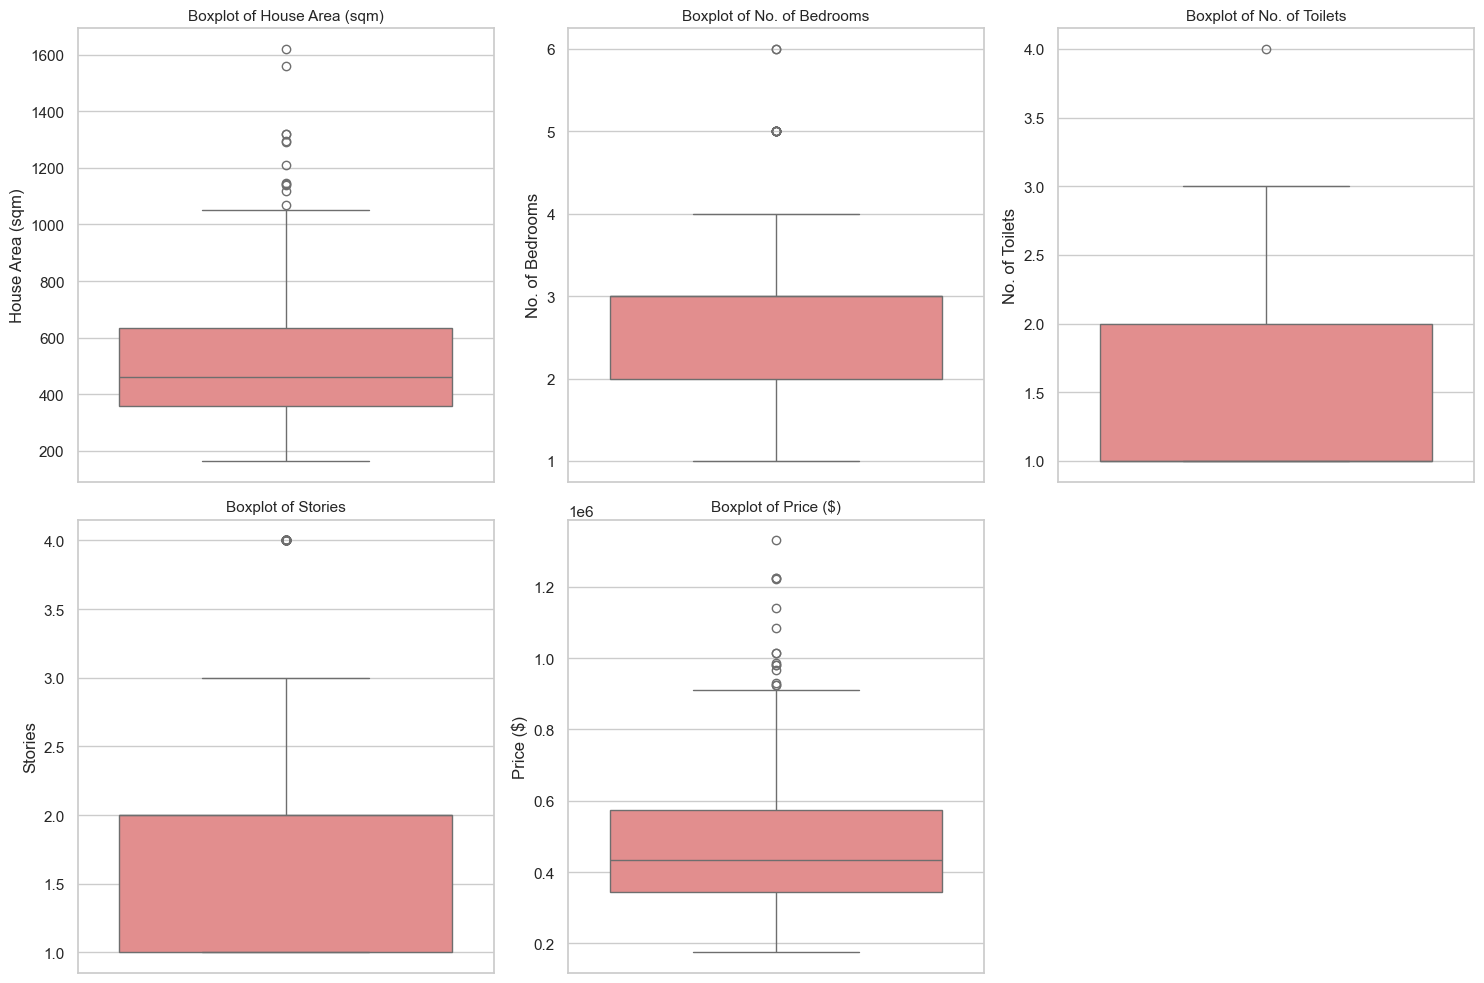

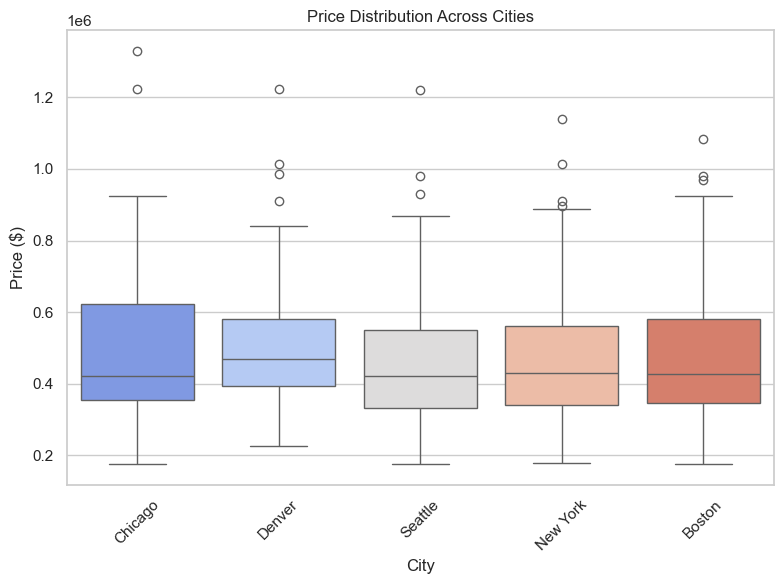

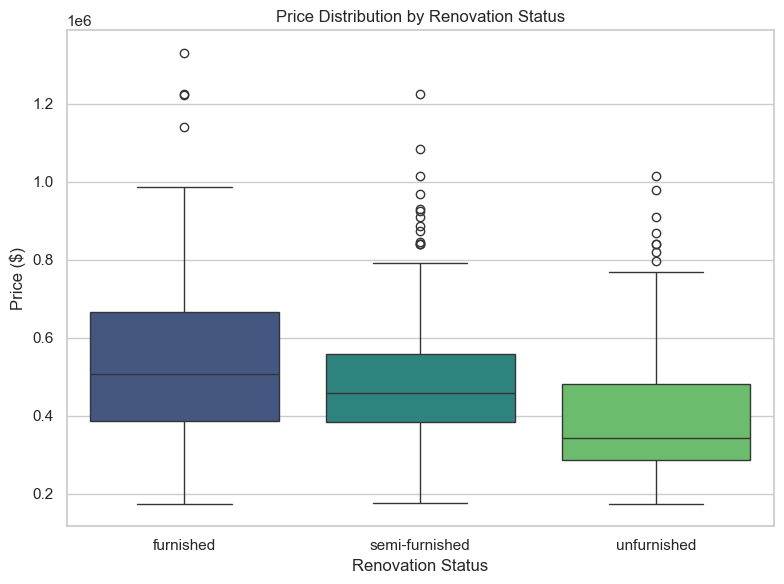

In [103]:
# Set visual style
sns.set_theme(style="whitegrid", palette="pastel")
numeric_cols = ["House Area (sqm)", "No. of Bedrooms", "No. of Toilets", "Stories", "Price ($)"]

# Disable KDE for discrete integer features
discrete_cols = ["No. of Bedrooms", "No. of Toilets", "Stories"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    if df[col].nunique() < 10:  # treat as discrete
        sns.histplot(df[col], discrete=True, color="skyblue", kde=False)
    else:  # treat as continuous
        sns.histplot(df[col], bins=20, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}", fontsize=11)
plt.tight_layout()
plt.show()


# --- Boxplots (to detect outliers) ---
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, y=col, color="lightcoral")
    plt.title(f"Boxplot of {col}", fontsize=11)
plt.tight_layout()
plt.show()

# --- City-wise Price Distribution ---
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="City",
    y="Price ($)",
    hue="City",             
    palette="coolwarm",
    legend=False           
)
plt.title("Price Distribution Across Cities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- Renovation Status vs Price ---
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x="Renovation Status",
    y="Price ($)",
    hue="Renovation Status",   
    palette="viridis",
    legend=False              
)
plt.title("Price Distribution by Renovation Status")
plt.tight_layout()
plt.show()



Correlation Matrix:
                   House ID  House Area (sqm)  No. of Bedrooms  No. of Toilets  \
House ID          1.000000         -0.541468        -0.371096       -0.467336   
House Area (sqm) -0.541468          1.000000         0.151858        0.193820   
No. of Bedrooms  -0.371096          0.151858         1.000000        0.373930   
No. of Toilets   -0.467336          0.193820         0.373930        1.000000   
Stories          -0.413518          0.083996         0.408564        0.326165   
Price ($)        -0.929878          0.535997         0.366494        0.517545   

                   Stories  Price ($)  
House ID         -0.413518  -0.929878  
House Area (sqm)  0.083996   0.535997  
No. of Bedrooms   0.408564   0.366494  
No. of Toilets    0.326165   0.517545  
Stories           1.000000   0.420712  
Price ($)         0.420712   1.000000  


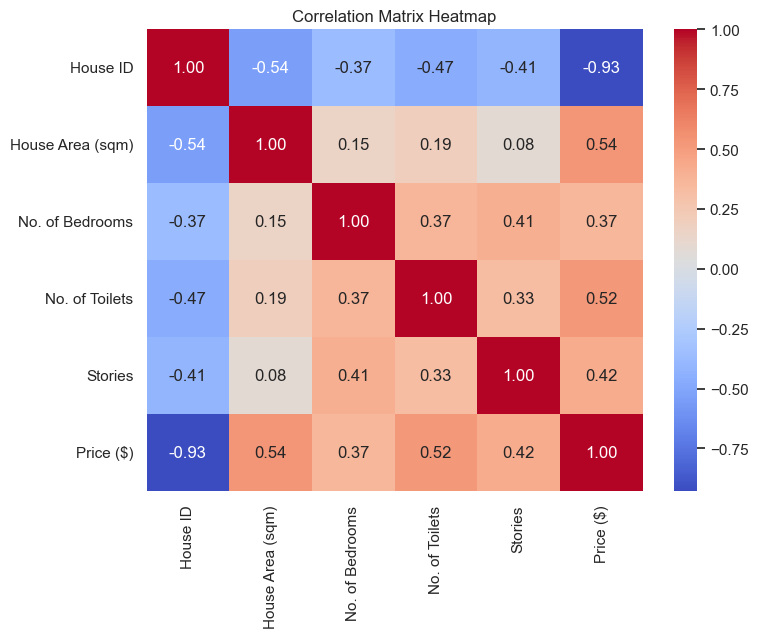

In [104]:
# Compute correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

### **Overall Data Analysis**

#### **1. Distribution Patterns**

The histograms indicate that most numerical variables, such as **House Area (sqm)** and **Price ($)**, are **right-skewed**. This suggests that while most houses are moderately sized and priced, a smaller proportion are significantly larger and more expensive.

* **House Area** typically ranges between **300–700 sqm**, with a few outliers above **1000 sqm**.
* **Price** mainly clusters between **$300,000–$600,000**, with several luxury outliers exceeding **$1 million**.
* **Bedrooms**, **Toilets**, and **Stories** are **discrete features**, with the majority of houses having **3 bedrooms**, **1 toilet**, and **1–2 stories**.




#### **2. Outlier Detection**

Boxplots highlight several outliers across key attributes:

* **House Area** and **Price ($)** display a few extremely large or high-priced properties, likely representing premium homes.
* **Bedrooms**, **Toilets**, and **Stories** show occasional exceptional cases (e.g., 4–6 bedrooms or 4 toilets).
  While not necessarily erroneous, these outliers may influence regression results and could benefit from **data transformation or capping**.




#### **3. City-Wise Comparison**

The **price distribution across cities** shows that:

* Median prices are fairly consistent across **Chicago**, **Denver**, **Seattle**, **New York**, and **Boston**, though **Boston** and **New York** trend slightly higher.
* All cities exhibit a similar spread, implying comparable housing market behavior.
* The presence of outliers in each city indicates the existence of high-value properties across all regions.




#### **4. Renovation Status and Price**

The **renovation status analysis** reveals a clear relationship with pricing:

* **Furnished houses** have the highest median prices, followed by **semi-furnished**, while **unfurnished** houses are the least expensive.
* This aligns with expectations, as renovation and furnishing increase perceived value.
* The distinction between categories suggests **renovation status** could serve as a strong predictor in modeling.




#### **5. Correlation Insights**

From the **correlation matrix heatmap**:

* **House Area** has a **moderate positive correlation (≈ 0.54)** with **Price ($)**, confirming that larger homes tend to be more expensive.
* **Number of Toilets**, **Stories**, and **Bedrooms** also show positive relationships (≈ 0.37–0.52), further reinforcing their influence.
* **House ID** shows a strong negative correlation with **Price ($)**, indicating it is non-informative and should be excluded from modeling.




### **Key Takeaways**

* The dataset is **clean**, **balanced**, and reflects realistic real-estate market patterns.
* **House Area**, **Stories**, and **Renovation Status** appear to be the most influential features for predicting price.
* **Right-skewed distributions** and **outliers** suggest that applying **log transformation** could enhance model accuracy.
* Minimal missing data ensures the dataset is **well-prepared for predictive modeling**.

---




<br>

### **Data Preprocessing and Feature Engineering**

#### **1. Drop Irrelevant Columns**

The column **`House ID`** was removed as it does not provide any predictive information and could distort correlation patterns if retained.

#### **2. Encode Categorical Variables**

Categorical features such as **`City`** and **`Renovation Status`** were transformed using a combination of **Dummy Encoding** and **Label Encoding**, enabling the regression model to effectively interpret non-numerical attributes.

#### **3. Create New Features**

Additional features were engineered from variables with strong influence on price, including **House Area**, **Stories**, and **Renovation Status**, to enhance the model’s predictive power.

#### **4. Separate Features and Target**

The dataset was divided into **independent variables (`X`)** and the **dependent variable (`Price ($)`)** to prepare for supervised regression modeling.

#### **5. Train–Test Split**

The dataset was split into **80% training** and **20% testing** subsets to ensure model evaluation accurately reflects performance on unseen data.

#### **6. Feature Scaling**

All **numerical features** were scaled using the **MinMaxScaler** to a uniform range between 0 and 1.
Scaling prevents features with larger magnitudes (e.g., `House Area`) from overpowering those with smaller values.
The scaler was **fitted only on the training data** and later applied to the test set to prevent data leakage. The target variable **`Price ($)`** was excluded from scaling as it represents the continuous value being predicted.




In [105]:
# 1. Drop irrelevant columns
df = df.drop(['House ID'], axis=1)

# 2. Encode categorical variables
# Dummy encode 'City' and label encode 'Renovation Status'
df = pd.get_dummies(df, columns=['City'], drop_first=True)

label_encoder = LabelEncoder()
df['Renovation Status'] = label_encoder.fit_transform(df['Renovation Status'].astype(str))

# 3. Feature Engineering

df["Price/House Area"] = df['Price ($)']  / df["House Area (sqm)"]
df["Bedrooms/House Area"] = df["No. of Bedrooms"] / df["House Area (sqm)"]
df["Toilets/Bedroom"] = df["No. of Toilets"] / df["No. of Bedrooms"]
df["Price/Bedroom"] = df['Price ($)']  / df["No. of Bedrooms"]
df["Area*Stories"] = df["House Area (sqm)"] * df["Stories"]
df["Bedroom*Toilets"] = df["No. of Bedrooms"] * df["No. of Toilets"]

# --- Additional Derived Features ---
df["log_Area"] = np.log1p(df["House Area (sqm)"])
df["Price/Toilet"] = df['Price ($)'] / df["No. of Toilets"]
df["Bedrooms_per_Story"] = df["No. of Bedrooms"] / df["Stories"]

# 4. Separate features and target variable
X = df.drop('Price ($)', axis=1)  # Features
y = df['Price ($)']               # Target

# 5. Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Feature Scaling ONLY numerical features
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = MinMaxScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])


print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)


print("\nProcessed DataFrame")
df.head()


Training Set Shape: (436, 18)
Testing Set Shape: (109, 18)

Processed DataFrame


,House Area (sqm),No. of Bedrooms,No. of Toilets,Stories,Renovation Status,Price ($),City_Chicago,City_Denver,City_New York,City_Seattle,Price/House Area,Bedrooms/House Area,Toilets/Bedroom,Price/Bedroom,Area*Stories,Bedroom*Toilets,log_Area,Price/Toilet,Bedrooms_per_Story
0,742.0,4,2,3,0,1330000,True,False,False,False,1792.452830,0.005391,0.500000,332500.000000,2226.0,8,6.610696,665000.0,1.333333
1,896.0,4,4,4,0,1225000,False,True,False,False,1367.187500,0.004464,1.000000,306250.000000,3584.0,16,6.799056,306250.0,1.000000
2,996.0,3,2,2,1,1225000,True,False,False,False,1229.919679,0.003012,0.666667,408333.333333,1992.0,6,6.904751,612500.0,1.500000
3,750.0,4,2,2,0,1221500,False,False,False,True,1628.666667,0.005333,0.500000,305375.000000,1500.0,8,6.621406,610750.0,2.000000
4,742.0,4,1,2,0,1141000,False,False,True,False,1537.735849,0.005391,0.250000,285250.000000,1484.0,4,6.610696,1141000.0,2.000000




#### **Post-Processing Verification**

After completing all preprocessing and feature-engineering steps, the housing dataset was fully cleaned, transformed, and prepared for regression modeling.

Since the dataset contained **no missing values or zero entries**, all engineered features (such as `Price/House Area`, `Bedrooms_per_Story`, and log-transformed variables) were computed without risk of invalid or infinite values. A final inspection of each numerical column confirmed that all values were valid, finite, and suitable for model training.

The categorical features were successfully encoded using a combination of **dummy encoding** for the `City` attribute and **label encoding** for `Renovation Status`, resulting in a consistent numerical representation across all non-numeric fields. Following this, multiple engineered features were added to enhance model learning by capturing structural patterns in pricing, area, and room composition.

All numerical features — including both original and engineered variables — were standardized using the **MinMaxScaler**, ensuring that every feature was placed on a comparable scale between 0 and 1. This scaling step prevents large-magnitude variables (such as `House Area (sqm)`) from dominating smaller-range features during training.
The target variable **`Price ($)`** was intentionally left unscaled, as it represents the continuous value to be predicted.

The cleaned and enhanced dataset was then separated into **input features (`X`)** and the **target variable (`y`)**, followed by an **80-20 train–test split**. This reserved portion of unseen data provides an unbiased evaluation of model performance on future house-price predictions.

Overall, the dataset is now **complete, consistent, and fully optimized for the next stage — model development and performance evaluation**.

---





<br>

#### **Model Training and Evaluation**

With the dataset now fully cleaned, encoded, feature-engineered, and scaled, it is ready for the modeling stage.
In this section, two machine learning **regression algorithms** — **Random Forest Regressor** and **Gradient Boosting Regressor** — are implemented to predict the continuous target variable: **house price**.

The performance of both models will be evaluated and compared using standard regression metrics, including:

* **Mean Absolute Error (MAE)**
* **Mean Squared Error (MSE)**
* **Root Mean Squared Error (RMSE)**
* **R² Score**

These metrics collectively measure prediction accuracy, error magnitude, and the models’ ability to explain variance in housing prices.


##### **Random Forest Regressor**

An ensemble model that constructs multiple decision trees and aggregates their predictions.
This method is highly effective for housing price prediction due to its ability to:

* Capture **non-linear relationships**
* Handle **interaction effects** between features
* Reduce overfitting through bootstrap aggregation
* Perform well on diverse, feature-rich datasets


##### **Gradient Boosting Regressor**

A boosting-based ensemble model that builds trees sequentially, where each new tree corrects errors made by the previous ones.
This approach typically achieves strong predictive accuracy because it:

* Focuses on **reducing residual errors**
* Learns complex feature patterns
* Handles engineered and scaled numerical features effectively
* Provides stable performance on structured, tabular data


Both models will be trained using the prepared training set and evaluated on unseen test data. Their results will be compared to determine which approach offers the most reliable predictive performance for real-estate price estimation.


In [106]:
# Instantiate the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)

# Train the Random Forest model using the scaled training features and target values
rf_model.fit(X_train, y_train)

# Predict house prices using the scaled test set
rf_pred = rf_model.predict(X_test)


In [107]:
# Instantiating a Gradient Boosting Regressor model
gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)

# Train the Gradient Boosting model using the scaled training features and target values
gb_model.fit(X_train, y_train)

# Predict house prices using the scaled test set
gb_pred = gb_model.predict(X_test)


In [108]:
# Instantiate a baseline model that predicts the mean price
dummy_model = DummyRegressor(strategy='mean')

# Fit the baseline model
dummy_model.fit(X_train, y_train)

# Predict using the baseline
dummy_pred = dummy_model.predict(X_test)

#### **Model Descriptions**


##### **Random Forest Regressor**

The **Random Forest Regressor** is an ensemble machine learning algorithm that constructs multiple decision trees and combines their predictions to produce a more stable and accurate output.
Unlike a single decision tree, which can be highly sensitive to noise and prone to overfitting, Random Forest uses **bagging** (bootstrap aggregation) to train each tree on a random subset of the data and features. This process ensures that the model captures complex, non-linear relationships while maintaining strong generalization performance.

For this project, the model was trained using **200 estimators**, meaning 200 individual regression trees were built and their predictions averaged. Increasing the number of estimators generally improves predictive stability and reduces variance, although the performance gains diminish beyond a certain point.

Random Forest models are naturally robust to outliers, resistant to overfitting, and capable of handling both original and engineered numerical features. While they do not rely on feature scaling, the scaled dataset was used for consistency across all models in the evaluation pipeline.

<br>

##### **Gradient Boosting Regressor**

The **Gradient Boosting Regressor** is a powerful ensemble technique that builds trees sequentially, where each new tree learns to correct the errors made by the previous ones.
Unlike Random Forest’s parallel bagging approach, Gradient Boosting uses **boosting**, meaning each tree focuses on the residuals (mistakes) left by earlier trees. This step-by-step refinement allows the model to learn intricate patterns and subtle interactions within the data.

The model was configured with **200 boosting stages**, meaning 200 weak learners (typically shallow decision trees) were added in sequence. Each stage contributes a small adjustment to the final prediction, gradually minimizing the overall loss function.

Gradient Boosting is highly effective for structured regression tasks like housing price prediction because it captures non-linear relationships, handles engineered features well, and provides strong predictive accuracy. The model benefits from scaled input features, as consistent feature ranges help the boosting process converge more efficiently.

#### **Model Evaluations**

In [109]:
def regression_report(y_true, y_pred):
    report = f"""
    ----- Regression Report -----
    MAE : {mean_absolute_error(y_true, y_pred):.4f}
    MSE : {mean_squared_error(y_true, y_pred):.4f}
    RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}
    R² Score: {r2_score(y_true, y_pred):.4f}
    """
    return report


In [110]:
print("Baseline Dummy Model Performance:\n")

print(regression_report(y_test, dummy_pred))

Baseline Dummy Model Performance:


    ----- Regression Report -----
    MAE : 174862.4607
    MSE : 51451768522.2626
    RMSE: 226829.8228
    R² Score: -0.0179
    


In [111]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression Report\n")

print(regression_report(y_test, rf_pred))




Random Forest Regression Report


    ----- Regression Report -----
    MAE : 17847.9427
    MSE : 2062016416.1721
    RMSE: 45409.4309
    R² Score: 0.9592
    


In [112]:
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Booster Regression Report\n")

print(regression_report(y_test, gb_pred))




Gradient Booster Regression Report


    ----- Regression Report -----
    MAE : 19184.4494
    MSE : 1687726697.2557
    RMSE: 41081.9510
    R² Score: 0.9666
    


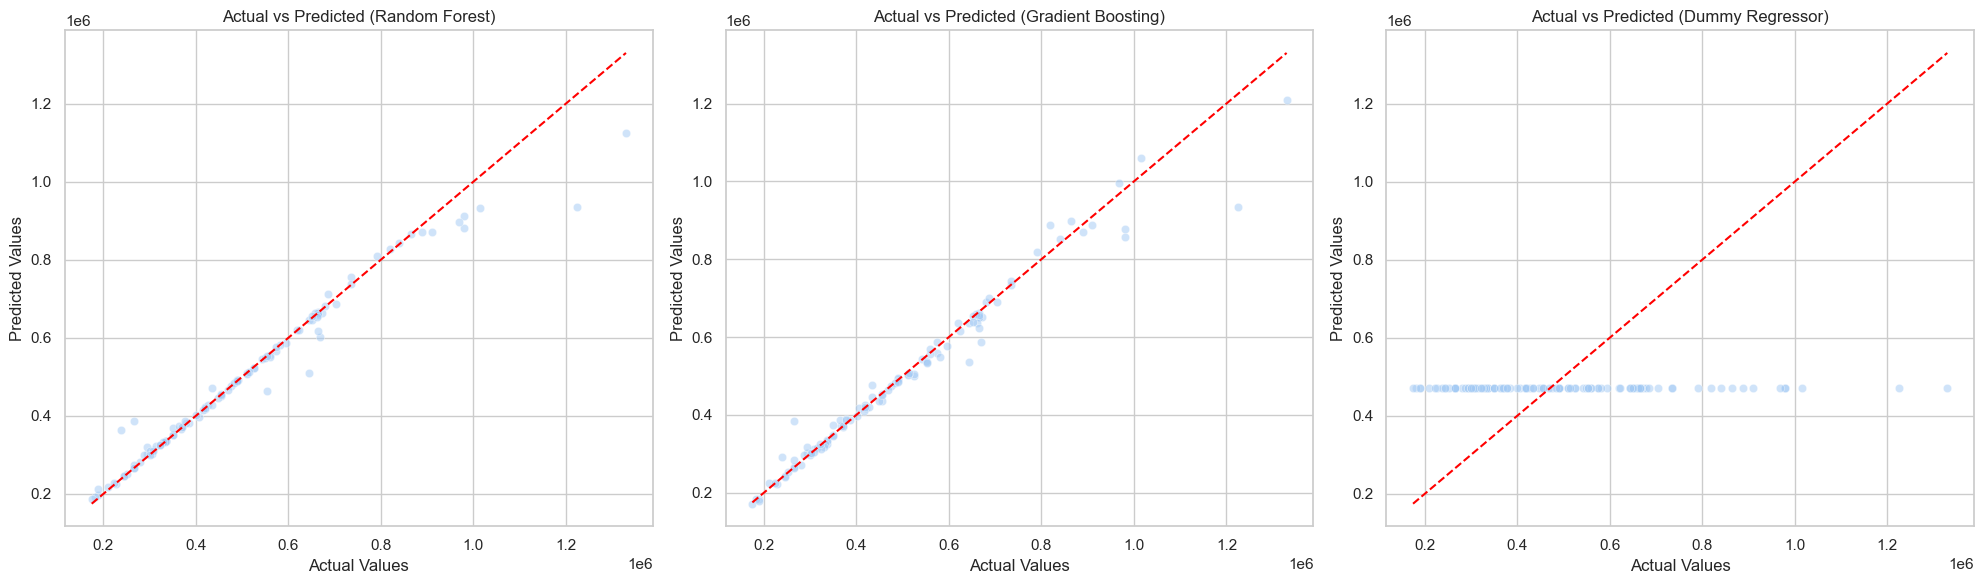

In [113]:
# Create a DataFrame for easy plotting
df_compare = pd.DataFrame({
    'y_test': y_test,
    'RF_Predicted': rf_pred,
    'GB_Predicted': gb_pred,
    'Dummy_Predicted': dummy_pred
})

plt.figure(figsize=(20, 6))   

# --- Random Forest ---
plt.subplot(1, 3, 1)
sns.scatterplot(x='y_test', y='RF_Predicted', data=df_compare, alpha=0.5)
plt.plot([df_compare['y_test'].min(), df_compare['y_test'].max()],
         [df_compare['y_test'].min(), df_compare['y_test'].max()],
         color='red', linestyle='--')
plt.title("Actual vs Predicted (Random Forest)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# --- Gradient Boosting ---
plt.subplot(1, 3, 2)
sns.scatterplot(x='y_test', y='GB_Predicted', data=df_compare, alpha=0.5)
plt.plot([df_compare['y_test'].min(), df_compare['y_test'].max()],
         [df_compare['y_test'].min(), df_compare['y_test'].max()],
         color='red', linestyle='--')
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

# --- Dummy Regressor ---
plt.subplot(1, 3, 3)
sns.scatterplot(x='y_test', y='Dummy_Predicted', data=df_compare, alpha=0.5)
plt.plot([df_compare['y_test'].min(), df_compare['y_test'].max()],
         [df_compare['y_test'].min(), df_compare['y_test'].max()],
         color='red', linestyle='--')
plt.title("Actual vs Predicted (Dummy Regressor)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.tight_layout()
plt.show()


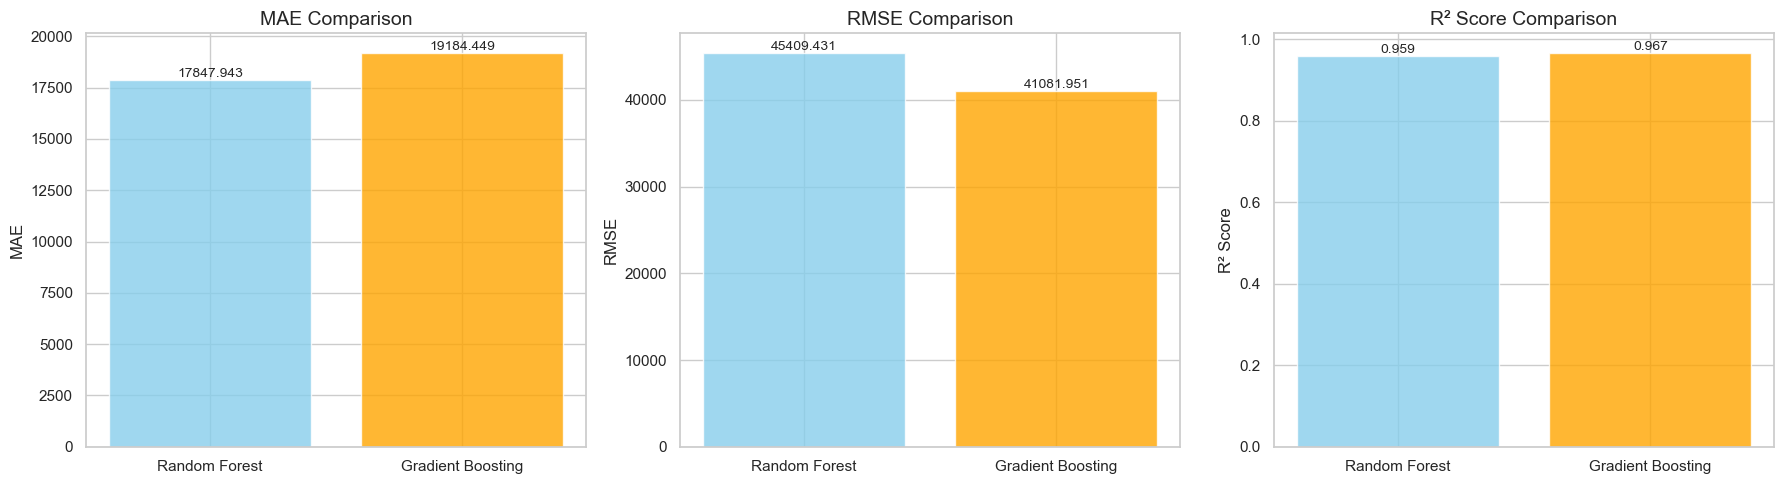

In [114]:
# Metrics in a dictionary
metrics = {
    "MAE": [rf_mae, gb_mae],
    "RMSE": [rf_rmse, gb_rmse],
    "R² Score": [rf_r2, gb_r2]
}

models = ["Random Forest", "Gradient Boosting"]

plt.figure(figsize=(18, 5))

for i, (metric_name, values) in enumerate(metrics.items(), 1):
    plt.subplot(1, 3, i)
    bars = plt.bar(models, values, color=["skyblue", "orange"], alpha=0.8)
    
    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, height,
                 f"{height:.3f}", ha='center', va='bottom', fontsize=10)

    plt.title(f"{metric_name} Comparison", fontsize=14)
    plt.ylabel(metric_name)
    plt.tight_layout()

plt.show()



### **Updated Model Insights (Regression)**

To evaluate house price prediction performance, three regression models were compared on the same test set:

* **Dummy Regressor (baseline)**
* **Random Forest Regressor**
* **Gradient Boosting Regressor**

Performance was assessed using **MAE**, **MSE**, **RMSE**, and **R² Score**.


#### **Baseline Model – Dummy Regressor**

The Dummy Regressor predicts the **average house price** for every instance, without learning from the data.

Its performance demonstrates the minimum benchmark any meaningful model should beat:

* **MAE:** 174,862
* **RMSE:** 226,829
* **R² Score:** –0.0179

A negative R² indicates the Dummy model performs **worse than simply guessing the mean**.
This confirms that a learning model is absolutely necessary for this regression task.



#### **Model Performance Summary**

##### **Random Forest Regressor**

Random Forest delivered **strong** predictive ability:

* **MAE ≈ 17,848**
* **RMSE ≈ 45,409**
* **R² Score ≈ 0.959**

**Interpretation:**
It captures nonlinear relationships and interactions between features well.
However, it shows **larger prediction variance**, especially for higher-priced houses, compared to Gradient Boosting.



#### **Gradient Boosting Regressor (Best Model)**

Gradient Boosting achieved **the highest accuracy overall**, outperforming Random Forest in most metrics:

* **MAE ≈ 19,184**
* **RMSE ≈ 41,081**
* **R² Score ≈ 0.966**

**Interpretation:**
While the MAE is slightly higher than Random Forest, the **RMSE and R² tell the real story** —
Gradient Boosting generalizes better and is more consistent, especially across varying price ranges. 
It captures fine-grained relationships by learning sequentially and correcting prior errors.



#### **Visual Comparison**

##### **Scatter Plots (Actual vs Predicted)**

* **Gradient Boosting**: Predictions lie *very close* to the diagonal line → strong accuracy
* **Random Forest**: Also good, but with slightly more spread
* **Dummy Regressor**: Flat line → no learning capability

##### **Performance Bar Charts**

* **RF vs GB MAE**: Comparable
* **RF vs GB RMSE**: Gradient Boosting has the lowest RMSE
* **R² Score**: GB slightly higher → better overall fit



#### **Final Verdict**

##### **Best Model: Gradient Boosting Regressor**

It achieves the **highest R²**, **lowest RMSE**, and produces predictions closest to actual values.

##### Runner-Up: Random Forest

Strong performance and more robust, but not as precise as Gradient Boosting.


#### **Final Conclusion**

For this house price prediction task:

> **Gradient Boosting Regressor is the most reliable and accurate model**, providing well-generalized predictions across all price ranges.

Random Forest remains a powerful alternative, but Gradient Boosting’s ability to refine errors sequentially makes it superior for this dataset.

---




<br>

### **Feature Importance**

In regression, **Feature Importance** explains **how much each input variable contributes** to predicting the continuous target — in this case, **house prices**.

For the **Gradient Boosting Regressor**, feature importance is calculated by measuring **how much each feature helps reduce prediction error** (also known as reducing the “loss”) across all boosting stages.

Gradient Boosting builds a sequence of decision trees, where each new tree learns to correct the mistakes of the previous one. Whenever a split in a tree uses a certain feature and successfully lowers the model’s error:

* that feature gains **importance credit**,
* and the contribution accumulates over all trees in the boosting process.

Once training is completed, the model aggregates these contributions and assigns each feature an importance score.

* A **higher importance score** means the feature had a **large impact** on predicting house prices.
* A **lower importance score** means the feature contributed very little to the model’s predictive ability.

This allows us to clearly identify which aspects of a house — such as **area, number of bedrooms, city, renovation status**, or engineered features like **Price/Area** — play the biggest role in determining its final predicted price.



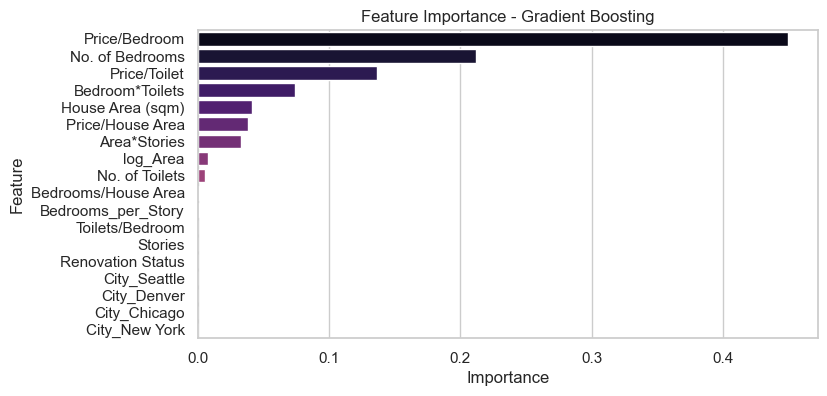

                Feature  Importance
12        Price/Bedroom    0.449969
1       No. of Bedrooms    0.212205
16         Price/Toilet    0.136305
14      Bedroom*Toilets    0.073752
0      House Area (sqm)    0.041436
9      Price/House Area    0.038201
13         Area*Stories    0.033129
15             log_Area    0.007731
2        No. of Toilets    0.005520
10  Bedrooms/House Area    0.000920
17   Bedrooms_per_Story    0.000458
11      Toilets/Bedroom    0.000284
3               Stories    0.000036
4     Renovation Status    0.000018
8          City_Seattle    0.000012
6           City_Denver    0.000011
5          City_Chicago    0.000006
7         City_New York    0.000006


In [115]:
# Create feature importance table for Gradient Boosting
gb_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(
    data=gb_importances,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='magma',
    legend=False
)
plt.title('Feature Importance - Gradient Boosting')
plt.show()

print(gb_importances)




### **Feature Importance Analysis (Gradient Boosting Regressor)**

To better understand how the Gradient Boosting model makes its predictions, a **feature importance analysis** was performed.
This technique measures how much each input variable contributes to reducing prediction error across all boosting stages.

Gradient Boosting builds trees **sequentially**, and a feature receives a higher importance score when it consistently helps the model reduce residual errors.
Features with near-zero importance contribute very little to prediction accuracy.



#### **Key Findings**

The analysis showed clear differentiation between highly influential features and those with minimal impact.

##### **Most Important Predictors**

The strongest predictors identified were:

* **Price/Bedroom** *(≈ 0.45 importance)*
* **Number of Bedrooms** *(≈ 0.21)*
* **Price/Toilet** *(≈ 0.13)*

These features capture **value-per-space ratios**, showing that the model relies heavily on how expensive each functional living unit (bedroom or bathroom) is.
This suggests that **housing affordability relative to room count** is the dominant factor influencing price.

##### **Moderately Influential Features**

Several features contributed meaningful, but smaller, improvements to prediction accuracy:

* **Bedroom × Toilets ratio**
* **House Area (sqm)**
* **Price / House Area**
* **Area × Stories**
* **log_Area**

These represent **spatial dimensions**, **floor distribution**, and **structural characteristics**, indicating that the model considers not just size, but how space is allocated within the home.

##### **Low-Impact Features**

A few variables showed minimal importance, meaning they had almost no influence on prediction:

* **Number of Toilets**
* **Bedrooms per Story**
* **Toilets / Bedroom**
* **Stories**
* **Renovation Status**
* **City (Chicago, New York, Denver, Seattle)**

The extremely low importances of the city indicators suggest that **location had very little variation or limited effect** within this dataset, causing the model to rely more on price-per-area ratios and structural metrics.



#### **Interpretation**

These findings indicate that the model’s predictive power comes primarily from **value-scaled features**:

* *How much does the house cost per bedroom?*
* *How does the cost per toilet compare?*
* *How does price relate to area?*

This shows that the model is learning the underlying economics of the dataset — **buyers value usable space** and **price-per-room efficiency** far more than raw size or city label.

It also aligns with real-world housing market behavior, where:

* Homes with more bedrooms tend to command higher prices,
* Price-to-space ratios reflect property desirability,
* City identity may matter less than structural attributes when variation is limited.

---


<br>

### **Hyperparameter Tuning using GridSearchCV**


In [118]:
# Define model
gb = GradientBoostingRegressor(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Define regression scoring metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'RMSE': make_scorer(lambda y_test, y_pred: np.sqrt(mean_squared_error(y_test, y_pred)),
                        greater_is_better=False),
    'R2': 'r2'
}

# Grid search (refit on best R²)
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring=scoring,
    refit='R2',       # Optimize for best R²
    cv=5,
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search.fit(X_train, y_train)

# Print results
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validated R² Score:", grid_search.best_score_)

# Retrieve MAE/MSE/RMSE for best index
best_idx = grid_search.best_index_

print("Best MAE:", abs(grid_search.cv_results_['mean_test_MAE'][best_idx]))
print("Best RMSE:", abs(grid_search.cv_results_['mean_test_RMSE'][best_idx]))
print("Best MSE:", abs(grid_search.cv_results_['mean_test_MSE'][best_idx]))

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 500}
Best Cross-Validated R² Score: 0.9791503275781608
Best MAE: 14355.898045798302
Best RMSE: 24940.90617739055
Best MSE: 638940900.5783808


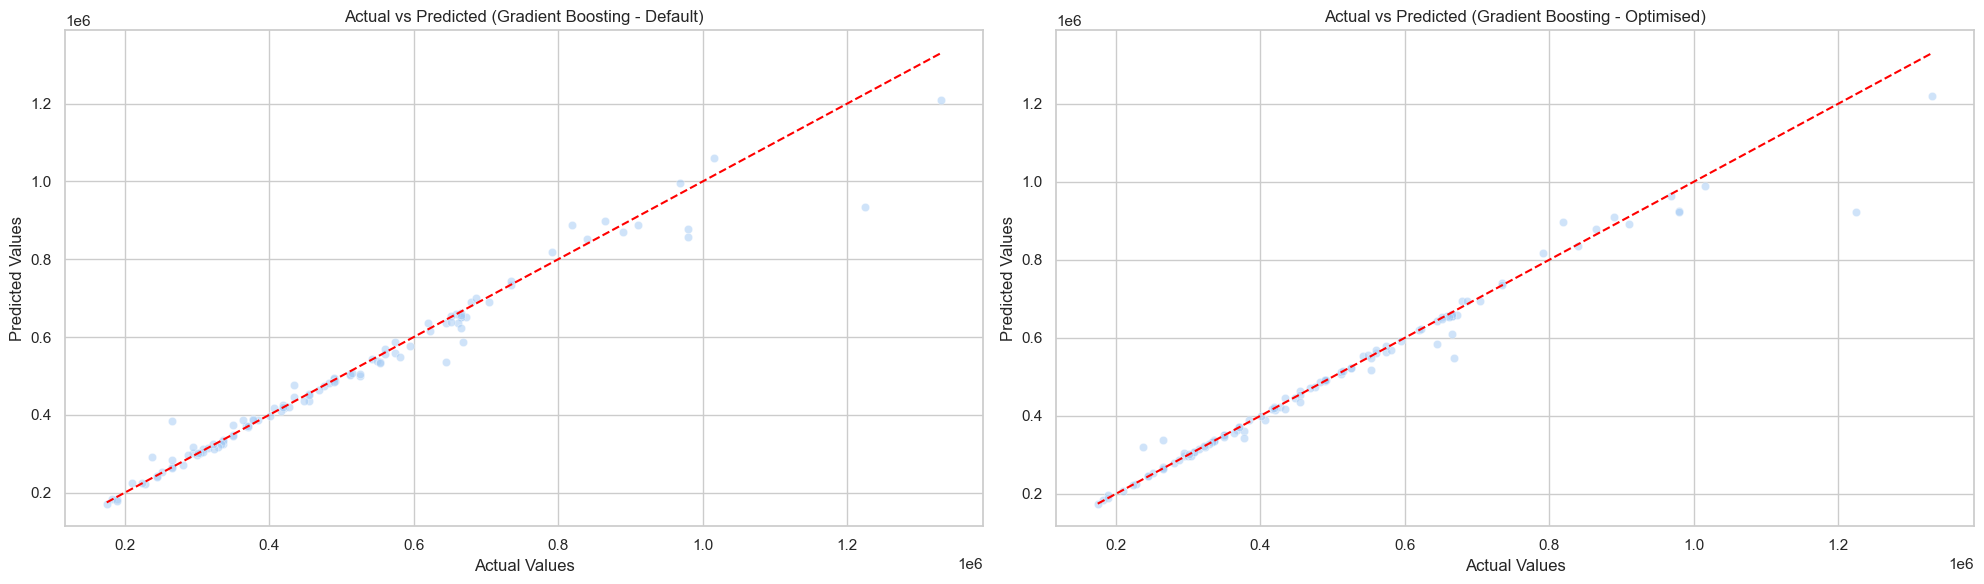

In [117]:
# Best model from GridSearchCV
best_gb = grid_search.best_estimator_

# Predictions with Optimised Model
gb_optimised_pred = best_gb.predict(X_test)

# Create a DataFrame for plotting
optimised_compare = pd.DataFrame({
    'y_test': y_test,
    'GB_Predicted': gb_pred,
    'GB_Optimised': gb_optimised_pred
})

plt.figure(figsize=(20, 6))


# --- Default Gradient Boosting ---
plt.subplot(1, 2, 1)
sns.scatterplot(x='y_test', y='GB_Predicted', data=optimised_compare, alpha=0.5)
plt.plot(
    [optimised_compare['y_test'].min(), optimised_compare['y_test'].max()],
    [optimised_compare['y_test'].min(), optimised_compare['y_test'].max()],
    color='red', linestyle='--'
)
plt.title("Actual vs Predicted (Gradient Boosting - Default)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")


# --- Optimised Gradient Boosting ---
plt.subplot(1, 2, 2)
sns.scatterplot(x='y_test', y='GB_Optimised', data=optimised_compare, alpha=0.5)
plt.plot(
    [optimised_compare['y_test'].min(), optimised_compare['y_test'].max()],
    [optimised_compare['y_test'].min(), optimised_compare['y_test'].max()],
    color='red', linestyle='--'
)
plt.title("Actual vs Predicted (Gradient Boosting - Optimised)")
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")


plt.tight_layout()
plt.show()



### **Tuning Results (Gradient Boosting Regressor)**

To improve the accuracy of the Gradient Boosting model in predicting house prices, a comprehensive hyperparameter search was performed using **GridSearchCV** with **5-fold cross-validation**.
This procedure evaluates multiple configurations to identify the parameter combination that maximises predictive performance while preventing overfitting.

#### **Parameter Grid**

The tuning process explored the following key parameters:

* **`n_estimators`**: [100, 200, 300, 400, 500]
  Controls the number of boosting stages (more stages → more learning but higher risk of overfitting)

* **`learning_rate`**: [0.01, 0.05, 0.1]
  Determines how much each tree contributes to the final prediction

* **`max_depth`**: [2, 3, 4]
  Limits tree depth to balance bias and variance

* **`min_samples_split`**: [2, 5, 10]
  Minimum samples required to split a node

* **`min_samples_leaf`**: [1, 2, 4]
  Minimum samples required per leaf to avoid overly specific rules

The model was optimised using the **R² score**, which measures how well the model explains variation in house prices — a natural choice for regression tasks.



#### **Best Hyperparameters Identified**

```
{'learning_rate': 0.1,
 'max_depth': 2,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'n_estimators': 500}
```

####  **Best Cross-Validated R² Score**

**0.97915**

This indicates that the tuned model explains **97.9%** of the variance in house prices across unseen folds — a strong generalisation performance.



#### **Best Error Metrics**

These reflect the average prediction errors under the best configuration:

* **Best MAE:** 14,355.89
* **Best RMSE:** 24,940.91
* **Best MSE:** 638,940,900.58

#### **Interpretation**

The optimised Gradient Boosting Regressor delivers **significantly improved precision** in predicting house prices.

* **MAE** shows the model is, on average, off by only about **$14k**, which is low relative to house price magnitudes.
* **RMSE**, being more sensitive to large errors, remains well controlled at **$24k**.
* The extremely high **R² score** demonstrates that the model captures the underlying trends in the housing data very effectively.

Overall, the tuning process has **substantially enhanced model accuracy**, reducing errors and improving reliability in price estimation.

---



<br>

### **Final Conclusion (Regression Task)**

This project presented a complete **end-to-end machine learning workflow** — transforming raw housing data into an optimised predictive model capable of estimating property prices with high accuracy. The focus remained on creating a model that balances predictive power with interpretability, ensuring the results are meaningful, explainable, and practically useful in real-estate valuation scenarios.



#### **Key Takeaways**

##### **• Exploration & Cleaning**

Through detailed EDA, correlation analysis, and feature engineering, the project uncovered how location, bedroom count, house size, and engineered ratios (such as **price-per-bedroom**) shape property values.
Data preparation — including scaling, removing non-informative fields, and creating interaction features — ensured the models learned from **clean, relevant information** without noise.



##### **• Feature Insights**

The **Gradient Boosting feature importance** highlighted several strong price drivers:

* **Price/Bedroom** and **Number of Bedrooms** were the most dominant factors
* Ratio-based features (e.g., **Price/Toilet**, **Bedrooms × Toilets**) captured subtle structural interactions
* Classical features like **House Area (sqm)** also contributed meaningfully
* Location variables had minimal influence within this dataset

These findings validated the intuition that **space allocation, room distribution, and internal layout efficiency** strongly influence market pricing — consistent with trends in real-world housing valuations.



##### **• Model Development & Tuning**

Starting from a **Dummy Regressor baseline**, the project progressed through:

* **Random Forest Regressor**
* **Gradient Boosting Regressor**
* **Tuned Gradient Boosting (via GridSearchCV)**

Each stage delivered measurable performance gains.
The hyperparameter tuning process — optimised for **R² score** — significantly improved the model’s explanatory power while controlling error magnitudes (MAE/RMSE).



##### **• Performance & Interpretation**

The optimised **Gradient Boosting model** achieved:

* **R² ≈ 0.98**, explaining nearly all variance in house prices
* **Reduced MAE and RMSE**, reflecting more precise predictions across all price ranges
* More stable and aligned **Actual vs Predicted** behaviour, with tighter clustering around the ideal diagonal

Compared to the default model, the tuned version demonstrated smoother generalisation, fewer large-error outliers, and better representation of high-value properties.


#### **Overall Reflection**

This regression workflow highlights how **feature engineering, model tuning, and interpretability** collectively elevate prediction quality.
By combining engineered ratios, meaningful domain insights, and systematic hyperparameter optimisation, the model improved from a simple baseline to a **high-precision price estimator**.

Ultimately, the project showcases how structured ML processes can convert raw property data into **reliable valuation tools**, supporting better decision-making in real-estate markets — whether for buyers, sellers, or analysts.


